In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from eval.data import load_and_split
from medal.model import AutoEncoder
from medal.normalizer import GlobalEmbeddingNormalizer
import torch
import matplotlib.colors as mcolors
from pathlib import Path
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split
from sklearn.metrics import jaccard_score
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
# Set MEDAL_DATA_DIR to your drd_data directory
import os
PATH_PREFIX = os.path.join(os.environ.get('MEDAL_DATA_DIR', os.path.join(os.path.expanduser('~'), 'drd_data')), 'tmp_results', 'normalize')
%load_ext autoreload
%autoreload 2

/home/bnc2119/.conda/envs/medal/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-29 12:06:15,228	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-04-29 12:06:15,632	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
# loading AE
def load_trained_ae(ckpt_path, input_dim, hidden_dims, latent_dim=2, batchnorm=False):
    import sys, os
    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, "w")
    model = AutoEncoder(
        input_dim=input_dim,
        latent_dim=latent_dim,
        hidden_dims=hidden_dims,
        activation=torch.nn.SELU,            
        bottleneck_activation=None,
        use_batchnorm = batchnorm
    )
    sys.stdout = old_stdout

    sd = torch.load(ckpt_path, map_location="cpu")

    if isinstance(sd, dict) and "model" in sd and isinstance(sd["model"], dict):
        sd = sd["model"]
    elif isinstance(sd, dict) and "state_dict" in sd and isinstance(sd["state_dict"], dict):
        sd = sd["state_dict"]

    sd = {k.replace("module.", ""): v for k, v in sd.items()}

    missing, unexpected = model.load_state_dict(sd, strict=False)
    print(f"loaded params: {len(sd)} | missing={len(missing)} | unexpected={len(unexpected)}")
    if missing or unexpected:
        print("⚠️ Check architecture/keys. Example missing:", missing[:3], "unexpected:", unexpected[:3])

    model.eval()
    return model


def plot_single_param_recon(student_embed, per_sample_recon, labels, 
                            student_embed_test = None, per_sample_recon_test = None, test_labels = None, 
                            fig = None, axes = None, palette = None, cmap = None, norm = None, plot_legend=False,
                            **fig_kwargs):
    if plot_legend:
        sns.scatterplot(x=student_embed[:, 0].detach().numpy(), 
                        y=student_embed[:, 1].detach().numpy(), 
                        ax=axes[0], s=4, hue=labels, legend=True, palette=palette)
        handles, labels = axes[0].get_legend_handles_labels()
        if getattr(axes[0], "legend_", None) is not None:
            axes[0].legend_.remove()

        # make one shared legend for the whole figure
        fig.legend(
            handles, labels,
            **fig_kwargs
        )
    else:
        sns.scatterplot(x=student_embed[:, 0].detach().numpy(), 
                        y=student_embed[:, 1].detach().numpy(), 
                        ax=axes[0], s=4, hue=labels, legend=False, palette=palette)
    sns.scatterplot(
        x=student_embed[:, 0].detach().numpy(), y=student_embed[:, 1].detach().numpy(),
        hue=per_sample_recon,
        palette=cmap, hue_norm=norm,
        s=8,legend=False, rasterized=True,
        ax=axes[1], 
    )
    if len(axes) == 4:
        sns.scatterplot(x=student_embed_test[:, 0].detach().numpy(), 
                        y=student_embed_test[:, 1].detach().numpy(),  
                        ax=axes[2], hue=test_labels, s=4, marker="x",linewidth=0.5, legend=False, alpha=1, palette=palette)
        sns.scatterplot(
            x=student_embed_test[:, 0].detach().numpy(), y=student_embed_test[:, 1].detach().numpy(),
            hue=per_sample_recon_test,
            palette=cmap, hue_norm=norm,marker="x",
            s=4, legend=False, rasterized=True,
            ax=axes[3], alpha=1, linewidth=0.5,
        )

def split_scdeed_labels(df, best_param):
    result = []
    for l in ["dubious", "trustworthy", "intermediate"]:
        vec = df.loc[best_param, f"{l}_cells"]
        ls_indices = np.array(vec.split(',')).astype(int)
        result.extend(list(zip([l]* len(ls_indices), ls_indices)))
    return pd.DataFrame(result, columns = ['label', 'index']).set_index('index').sort_index()

In [3]:
X_og, X_test, y_og, y_test = load_and_split("macaque", test_size=0.2, seed=0, labels=True)
X, X_val, y, y_val = train_test_split(X_og, y_og, test_size=0.2, random_state=0)

In [13]:
cmap = plt.get_cmap("tab20")
cell_types = np.unique(y)
c_dict = {
    'Cones': '#E63946',  # red
    'HC':    '#2196F3',  # blue
    'RGC':   '#FF9800',  # orange
    'MG':    '#4CAF50',  # green
    'BC':    '#9C27B0',  # purple
    'AC':    '#00BCD4',  # cyan
    'Rods':  '#F06292',  # pink
    'Endo':  '#8D6E63',  # brown
    'Mic':   '#78909C',  # slate
    'Peri':  '#CDDC39',  # yellow-green
}


In [ ]:
macaque_umap_res_dict = []
for s in range(5):
    for n in np.unique(np.logspace(np.log10(5), np.log10(500), 15).astype(int)):
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/macaque_umap_{n}_0.1_0_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/macaque/medal_umap2_{n}_0.1_tc0_{s}_ckpts/final.pt",
                input_dim=100,
                hidden_dims=[512] * 4,
                latent_dim=2, batchnorm=True)
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        
        if train_distill < 1e-5:
            train_recon = np.mean((student_recon.detach().numpy() - X)**2)
            macaque_umap_res_dict.append({"n_neighbors": n, "recon_loss": train_recon, "split": "Train", "seed": s})

            x_val_recon, _ = student(torch.tensor(X_val, dtype=torch.float32))
            val_recon = np.mean((x_val_recon.detach().numpy() - X_val)**2)
            macaque_umap_res_dict.append({"n_neighbors": n, "recon_loss": val_recon, "split": "Val", "seed": s})
        
            x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
            test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
            macaque_umap_res_dict.append({"n_neighbors": n, "recon_loss": test_recon, "split": "Test", "seed": s})
        else:
            print(f"Skipping param {perp} seed {s} due to distillation loss {train_distill}")

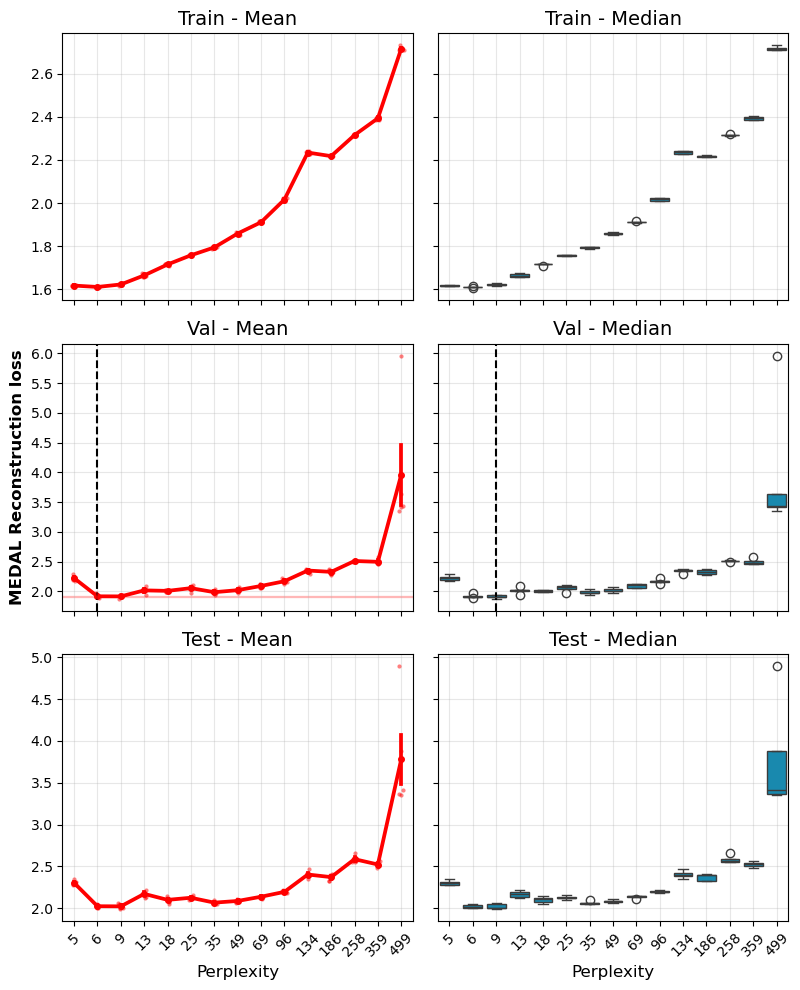

In [6]:
analysis = pd.DataFrame(macaque_umap_res_dict)
analysis.sort_values(by='n_neighbors', inplace=True)
test_stats = analysis[analysis.split == "Val"].groupby('n_neighbors')['recon_loss'].agg(['mean', 'median', 'sem'])
tsne_argmin_mean = test_stats['mean'].idxmin()
tsne_argmin_median = test_stats['median'].idxmin()
tsne_one_std_range = (test_stats.loc[tsne_argmin_mean, "mean"] - test_stats.loc[tsne_argmin_mean, "sem"], 
                test_stats.loc[tsne_argmin_mean, "mean"] + test_stats.loc[tsne_argmin_mean, "sem"])
tsne_one_std_param_choice = test_stats.loc[(test_stats['mean'] <= tsne_one_std_range[1]) & 
                                           (test_stats['mean'] >= tsne_one_std_range[0])].index.min()
x_coords = range(-1, len(test_stats)+1)

unique_neighbors = sorted(analysis['n_neighbors'].unique())
pos_mean = unique_neighbors.index(tsne_argmin_mean)
pos_median = unique_neighbors.index(tsne_argmin_median)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(8, 10), sharey='row', sharex=True)
for i, split in enumerate(['Train','Val', 'Test']):
    subset = analysis[analysis.split == split]
    
    # Left Column: Pointplot + Stripplot
    ax_point = axes[i, 0]
    sns.pointplot(data=subset, x="n_neighbors", y="recon_loss", errorbar="se", 
                  color="red", ax=ax_point, markersize=3)
    sns.stripplot(data=subset, x="n_neighbors", y="recon_loss", 
                  color="red", size=3, alpha=0.5, ax=ax_point)
    
    ax_point.set_title(f"{split} - Mean", fontsize=14)
    
    # Right Column: Boxplot
    ax_box = axes[i, 1]
    sns.boxplot(data=subset, x="n_neighbors", y="recon_loss", ax=ax_box, color='#0096C7')
    ax_box.set_title(f"{split} - Median", fontsize=14)
    
    for ax in [ax_point, ax_box]:
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Perplexity", fontsize=12)
        ax.set_ylabel("")
        plt.setp(ax.get_xticklabels(), rotation=45, ha='center')
        
    if split == "Val":
        ax_point.axvline(x=test_stats.index.get_loc(tsne_one_std_param_choice), ls='--', c='black')
        ax_box.axvline(x=pos_median, ls='--', c='black')

axes[1,0].fill_between(
    x_coords, 
    tsne_one_std_range[0], 
    tsne_one_std_range[1], 
    color="red", 
    alpha=0.2, 
    label='1 SEM'
)
axes[1,0].set_xlim(-0.5,14.5)
axes[1,0].set_ylabel("MEDAL Reconstruction loss", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [9]:
PATH_PREFIX = os.environ.get('MEDAL_DATA_DIR', os.path.join(os.path.expanduser('~'), 'drd_data'))
student = load_trained_ae(os.path.join(PATH_PREFIX, 'tmp_results/chkpt_teacher_seed/macaque/medal_umap2_6_0.1_tc0_0_ckpts/final.pt'),
                input_dim=100,
                hidden_dims=[512] * 4,
                latent_dim=2, batchnorm=True)
student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
student_test_recon, student_test_embed = student(torch.tensor(X_test, dtype=torch.float32))
per_sample_recon = np.mean((student_recon.detach().numpy() - X)**2, axis=1)
per_sample_test_recon = np.mean((student_test_recon.detach().numpy() - X_test)**2, axis=1)

/tmp/ipykernel_41706/1580406936.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0


In [10]:
macaque2 = pd.read_csv(Path(PATH_PREFIX) /'macaque2_pc100.csv')
macaque3 = pd.read_csv(Path(PATH_PREFIX) / 'macaque3_pc100.csv')
_, macaque2_test = train_test_split(macaque2, test_size=9600, random_state=0)
_, macaque3_test = train_test_split(macaque3, test_size=9600, random_state=0)
X2, y2 = macaque2_test.drop('labels', axis=1).values, macaque2_test['labels'].values
X3, y3 = macaque3_test.drop('labels', axis=1).values, macaque3_test['labels'].values
X2_aug, X3_aug = np.vstack([X2, X_test]), np.vstack([X3, X_test])
y2_aug, y3_aug = np.concatenate([y2, y_test]), np.concatenate([y3, y_test])
m_id2 = np.array(['M2 (OOD)'] * len(y2)+['M1 (in-dist)'] * len(y_test))
m_id3 = np.array(['M3 (OOD)'] * len(y3)+['M1 (in-dist)'] * len(y_test))

In [11]:
batch_recon2, batch_embed2 = student(torch.tensor(X2_aug, dtype=torch.float32))
per_sample_recon_2 = np.mean((batch_recon2.detach().numpy() - X2_aug)**2, axis=1)
batch_recon3, batch_embed3 = student(torch.tensor(X3_aug, dtype=torch.float32))
per_sample_recon_3 = np.mean((batch_recon3.detach().numpy() - X3_aug)**2, axis=1)

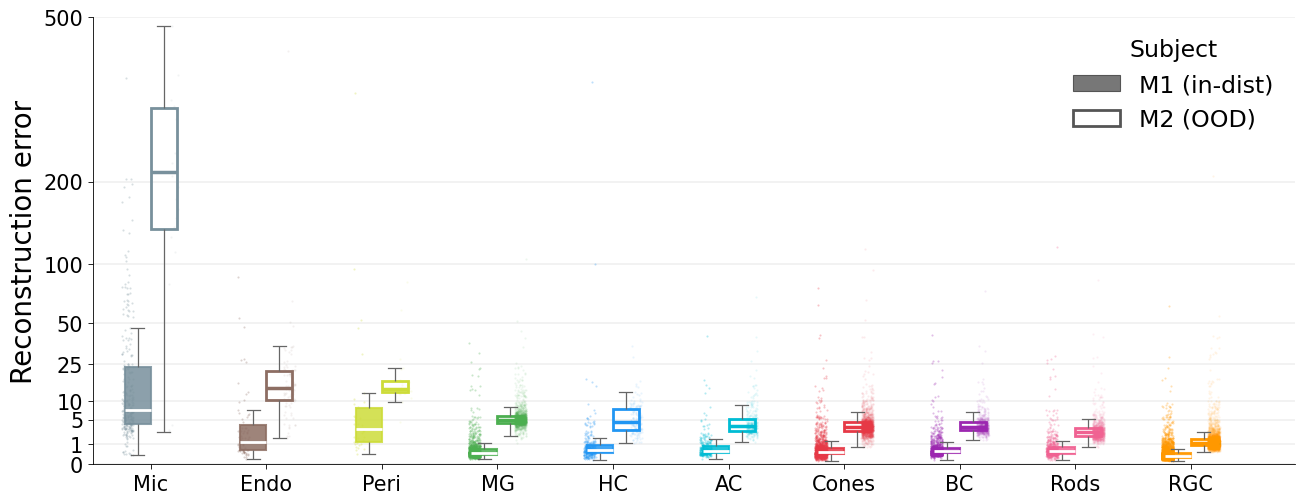

In [18]:
combined = pd.DataFrame({"cell_type": y2_aug, "Subject": m_id2, "recon_err": per_sample_recon_2})

medians = (
    combined
    .groupby(['cell_type', 'Subject'])['recon_err']
    .median()
    .unstack('Subject')
)
medians['diff'] = (medians['M2 (OOD)'] - medians['M1 (in-dist)']).abs()
cell_order = medians.sort_values('diff', ascending=False).index.tolist()
subject_order = ['M1 (in-dist)', 'M2 (OOD)']
n_ct, n_sub   = len(cell_order), len(subject_order)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Liberation Sans', 'DejaVu Sans'],
    'font.size': 11, 'axes.labelsize': 11, 'axes.titlesize': 12,
    'xtick.labelsize': 15, 'ytick.labelsize': 15,
    'axes.linewidth': 0.6, 'xtick.major.width': 0.6, 'ytick.major.width': 0.6,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

fig, ax = plt.subplots(figsize=(13, 5))

def recolor_by_group(items, get_x_fn, apply_fn):
    tagged = sorted([(get_x_fn(obj), obj) for obj in items], key=lambda t: t[0])
    groups = {}
    for x, obj in tagged:
        ci = np.clip(int(round(x)), 0, n_ct - 1)
        groups.setdefault(ci, []).append((x, obj))
    for ci, members in groups.items():
        members.sort(key=lambda t: t[0])  
        for si, (_, obj) in enumerate(members):
            if si < n_sub:
                apply_fn(obj, ci, si)

# ── Strip plot ───────────────────────────────────────────────────────────
n_coll_before = len(ax.collections)
sns.stripplot(
    data=combined, x='cell_type', y='recon_err', hue='Subject',
    order=cell_order, hue_order=subject_order,
    palette={s: '#aaaaaa' for s in subject_order},
    dodge=True, size=1.5, jitter=True, linewidth=0,
    legend=False, ax=ax, zorder=1,
)
new_colls = ax.collections[n_coll_before:]

def apply_strip(coll, ci, si):
    color = c_dict[cell_order[ci]]
    coll.set_facecolor(color)
    coll.set_alpha(0.30 if si == 0 else 0.10)

recolor_by_group(new_colls,
                 lambda c: float(np.mean(c.get_offsets()[:, 0])) if len(c.get_offsets()) else 0.,
                 apply_strip)

# ── Boxplot ──────────────────────────────────────────────────────────────
n_patch_before = len(ax.patches)
sns.boxplot(
    data=combined, x='cell_type', y='recon_err', hue='Subject',
    order=cell_order, hue_order=subject_order,
    palette={s: '#aaaaaa' for s in subject_order},
    width=0.45, showcaps=True,
    boxprops={'linewidth': 1.5},
    medianprops={'linewidth': 2.0, 'color': 'white'},
    whiskerprops={'linewidth': 0.9},
    capprops={'linewidth': 0.9},
    showfliers=False, dodge=True, ax=ax, zorder=2,
)
new_patches = [p for p in ax.patches[n_patch_before:]
               if isinstance(p, mpatches.PathPatch)]

def apply_box(patch, ci, si):
    color = c_dict[cell_order[ci]]
    if si == 0:
        patch.set_facecolor(color)
        patch.set_edgecolor(color)
        patch.set_alpha(0.85)
    else:
        patch.set_facecolor('none')
        patch.set_edgecolor(color)
        patch.set_linewidth(2.0)
        patch.set_alpha(1.0)          
        
recolor_by_group(new_patches,
                 lambda p: float(np.mean(p.get_path().vertices[:, 0])),
                 apply_box)
for line in ax.lines:
    x_data = line.get_xdata()
    if len(x_data) == 2 and line.get_linewidth() >= 1.8:
        x_mid = float(np.mean(x_data))
        ci = np.clip(int(round(x_mid)), 0, n_ct - 1)
        color = c_dict[cell_order[ci]]
        if x_mid > ci:
            line.set_color(color)       
            line.set_linewidth(2.5)
        else:
            line.set_color('white')     
ax.set_yscale('function', functions=(
    lambda x: np.sqrt(np.clip(x, 0, None)),   
    lambda x: x**2
))
ax.set_xlim(-0.5, n_ct - 0.5 + 0.4)
ax.set_ylabel('Reconstruction error', labelpad=4, fontsize=20)
ax.set_xlabel('')
ymax = combined['recon_err'].max()
ax.set_ylim(0, 200)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(0.6)
ax.grid(axis='y', linewidth=0.35, color='gray', alpha=0.4, zorder=0)
ax.set_axisbelow(True)

ax.set_yticks([0, 1, 5, 10, 25, 50, 100, 200, 500])

legend_handles = [
    mpatches.Patch(facecolor='#777777', edgecolor='#555555',
                   linewidth=0.8, label='M1 (in-dist)'),
    mpatches.Patch(facecolor='none', edgecolor='#555555',
                   linewidth=2.0, label='M2 (OOD)'),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=17,
          loc='upper right', title='Subject', title_fontsize=17)

plt.tight_layout(pad=0.5)
plt.show()

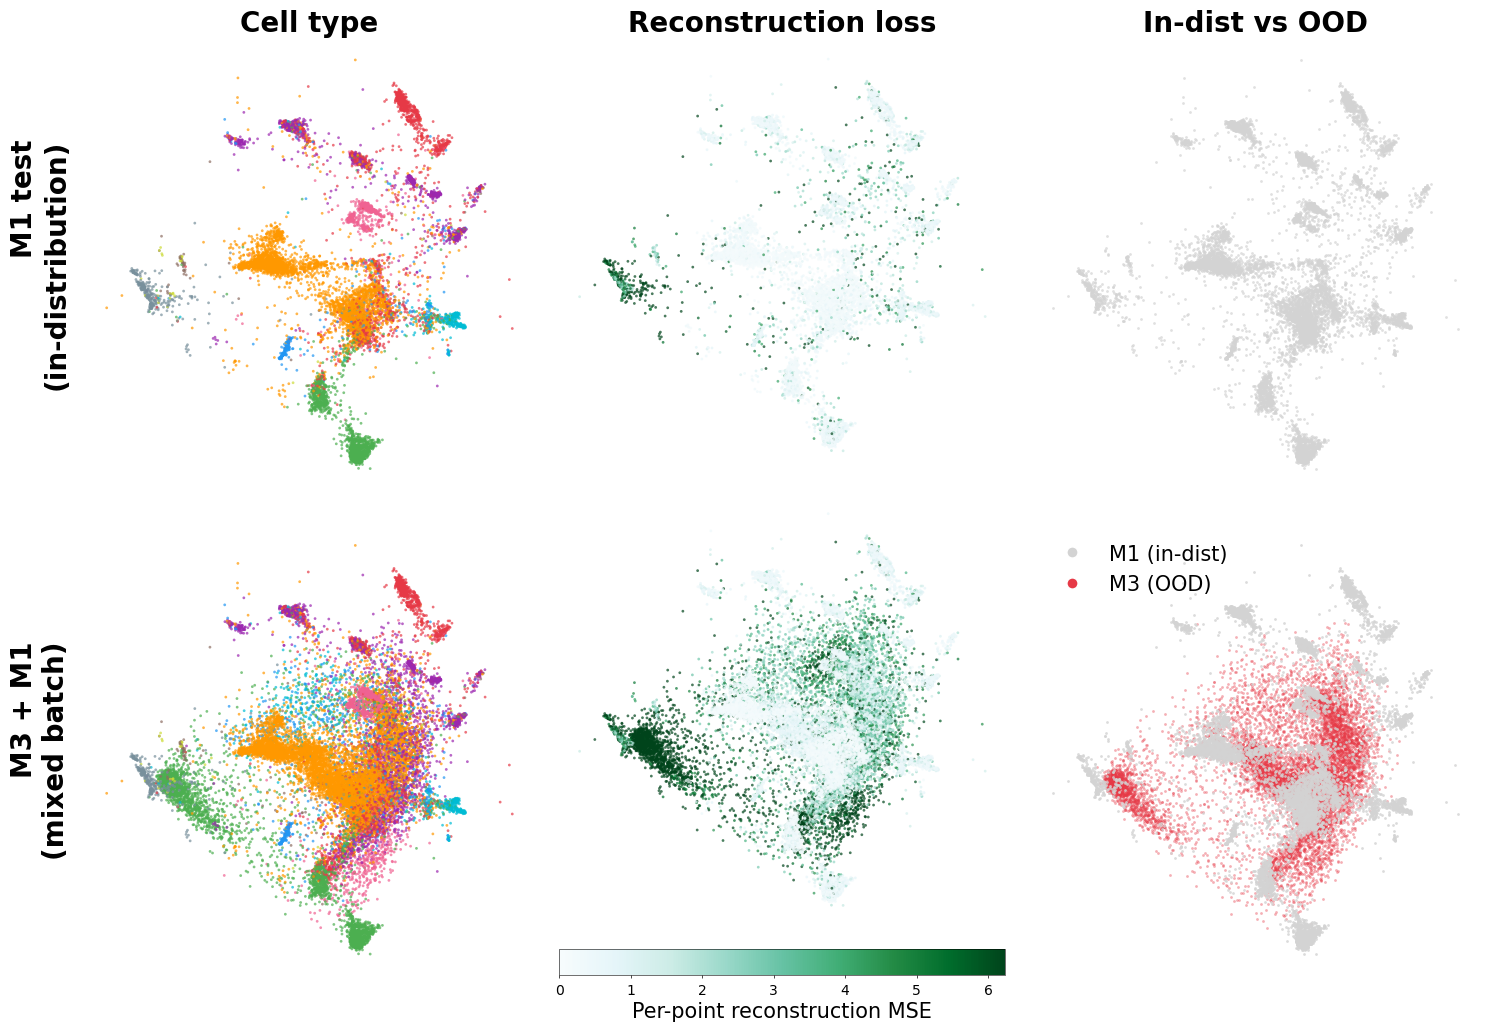

In [49]:
plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.sans-serif':  ['Arial', 'Liberation Sans', 'DejaVu Sans'],
    'font.size':        11,
    'pdf.fonttype':     42,
    'ps.fonttype':      42,
})

recon_cmap = sns.color_palette("BuGn", as_cmap=True)

# shared recon colorscale across both rows
all_recon   = np.concatenate([per_sample_test_recon, per_sample_recon_3])
vmax_shared = np.quantile(all_recon, 0.9)
shared_norm = plt.Normalize(vmin=0, vmax=vmax_shared)
indist_color = '#D3D3D3'  
ood_color    = '#E63946'   
ood_labels_test = np.array(['M1 (in-dist)'] * len(y_test))
ood_labels_mix  = np.array(['M3 (OOD)'] * len(y3)+['M1 (in-dist)'] * len(y_test))

ood_palette = {
    'M1 (in-dist)': indist_color,
    'M3 (OOD)':     ood_color,
}
fig = plt.figure(figsize=(16, 11))
gs_outer = GridSpec(1, 3, figure=fig, wspace=0.06,
                    left=0.1, right=0.97, top=0.93, bottom=0.08)


gs_col0 = GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_outer[0], hspace=0.08)
gs_col2 = GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_outer[2], hspace=0.08)
gs_col1 = GridSpecFromSubplotSpec(3, 1, subplot_spec=gs_outer[1],
                                   height_ratios=[1, 1, 0.06], hspace=0.08)

ax_test_cell  = fig.add_subplot(gs_col0[0])
ax_mix_cell   = fig.add_subplot(gs_col0[1])

ax_test_recon = fig.add_subplot(gs_col1[0])
ax_mix_recon  = fig.add_subplot(gs_col1[1])
cax           = fig.add_subplot(gs_col1[2])   

ax_test_ood   = fig.add_subplot(gs_col2[0])
ax_mix_ood    = fig.add_subplot(gs_col2[1])


col_titles = ['Cell type', 'Reconstruction loss', 'In-dist vs OOD']
for ax, title in zip([ax_test_cell, ax_test_recon, ax_test_ood], col_titles):
    ax.set_title(title, fontsize=20, fontweight='bold', pad=6)

for ax, label in [(ax_test_cell, 'M1 test\n(in-distribution)'),
                  (ax_mix_cell,  'M3 + M1\n(mixed batch)')]:
    bbox = ax.get_position()
    fig.text(bbox.x0 - 0.01,
             bbox.y0 + bbox.height / 2,
             label, ha='right', va='center',
             fontsize=20, fontweight='bold', rotation=90)

def clean_ax(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis('off')

Z_test = student_test_embed.detach().numpy() if hasattr(student_test_embed, 'detach') \
         else np.array(student_test_embed)
ax_test_cell.scatter(Z_test[:, 0], Z_test[:, 1],
                     c=[c_dict[ct] for ct in y_test],
                     s=4, linewidths=0, alpha=0.7, rasterized=True)
clean_ax(ax_test_cell)
ax_test_recon.scatter(Z_test[:, 0], Z_test[:, 1],
                      c=per_sample_test_recon, cmap=recon_cmap,
                      norm=shared_norm, s=4, linewidths=0,
                      alpha=0.7, rasterized=True)
clean_ax(ax_test_recon)
ax_test_ood.scatter(Z_test[:, 0], Z_test[:, 1],
                    c=indist_color, s=4, linewidths=0,
                    alpha=0.7, rasterized=True)
clean_ax(ax_test_ood)

Z_mix = batch_embed3.detach().numpy() if hasattr(batch_embed3, 'detach') \
        else np.array(batch_embed3)
ax_mix_cell.scatter(Z_mix[:, 0], Z_mix[:, 1],
                    c=[c_dict.get(ct, '#aaaaaa') for ct in y3_aug],
                    s=4, linewidths=0, alpha=0.7, rasterized=True)
clean_ax(ax_mix_cell)
ax_mix_recon.scatter(Z_mix[:, 0], Z_mix[:, 1],
                     c=per_sample_recon_3, cmap=recon_cmap,
                     norm=shared_norm, s=4, linewidths=0,
                     alpha=0.7, rasterized=True)
clean_ax(ax_mix_recon)
m3_mask = ood_labels_mix == 'M3 (OOD)'
m1_mask = ood_labels_mix == 'M1 (in-dist)'

ax_mix_ood.scatter(Z_mix[m3_mask, 0], Z_mix[m3_mask, 1],
                   c=ood_color, s=4, linewidths=0,
                   alpha=0.4, rasterized=True, zorder=1)   # M2 behind, transparent
ax_mix_ood.scatter(Z_mix[m1_mask, 0], Z_mix[m1_mask, 1],
                   c=indist_color, s=4, linewidths=0,
                   alpha=0.8, rasterized=True, zorder=2)   # M1 on top, opaque
clean_ax(ax_mix_ood)

sm = plt.cm.ScalarMappable(cmap=recon_cmap, norm=shared_norm)
cb = fig.colorbar(sm, cax=cax, orientation='horizontal')
cb.set_label('Per-point reconstruction MSE', fontsize=15, labelpad=3)
cb.ax.tick_params(labelsize=10, width=0.5, length=2.5)
cb.outline.set_linewidth(0.4)

ood_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=color, markersize=8, label=label)
    for label, color in ood_palette.items()
]
ax_mix_ood.legend(
    handles=ood_handles,
    loc='upper left', frameon=False,
    facecolor='white', edgecolor='#cccccc',
    framealpha=0.9, fontsize=15,
)

fig.subplots_adjust(left=0.1)

plt.show()

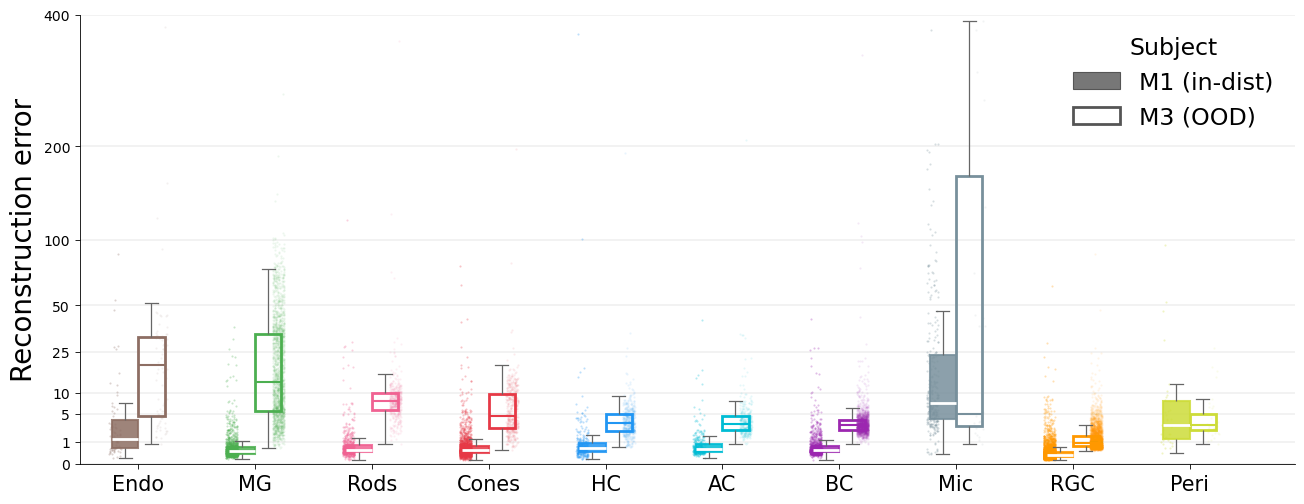

In [45]:
combined = pd.DataFrame({"cell_type": y3_aug, "Subject": m_id3, "recon_err": per_sample_recon_3})
medians = (
    combined
    .groupby(['cell_type', 'Subject'])['recon_err']
    .median()
    .unstack('Subject')
)
medians['diff'] = (medians['M3 (OOD)'] - medians['M1 (in-dist)']).abs()
cell_order = medians.sort_values('diff', ascending=False).index.tolist()
subject_order = ['M1 (in-dist)', 'M3 (OOD)']
n_ct, n_sub   = len(cell_order), len(subject_order)


plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.sans-serif':  ['Arial', 'Liberation Sans', 'DejaVu Sans'],
    'font.size':        11,
    'axes.labelsize':   11,
    'axes.titlesize':   12,
    'xtick.labelsize':  15,
    'ytick.labelsize':  10,
    'axes.linewidth':   0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'pdf.fonttype':     42,
    'ps.fonttype':      42,
})


subject_palette = {
    'M1 (in-dist)': '#2C5F8A',
    'M3 (OOD)':     '#E08B2A',
}

fig, ax = plt.subplots(figsize=(13, 5))
n_coll_before = len(ax.collections)
sns.stripplot(
    data=combined, x='cell_type', y='recon_err', hue='Subject',
    order=cell_order, hue_order=subject_order,
    palette={s: '#aaaaaa' for s in subject_order},
    dodge=True, size=1.5, jitter=True, linewidth=0,
    legend=False, ax=ax, zorder=1,
)
new_colls = ax.collections[n_coll_before:]

recolor_by_group(new_colls,
                 lambda c: float(np.mean(c.get_offsets()[:, 0])) if len(c.get_offsets()) else 0.,
                 apply_strip)
n_patch_before = len(ax.patches)
sns.boxplot(
    data=combined, x='cell_type', y='recon_err', hue='Subject',
    order=cell_order, hue_order=subject_order,
    palette={s: '#aaaaaa' for s in subject_order},
    width=0.45, showcaps=True,
    boxprops={'linewidth': 1.5},
    medianprops={'linewidth': 2.0, 'color': 'white'},
    whiskerprops={'linewidth': 0.9},
    capprops={'linewidth': 0.9},
    showfliers=False, dodge=True, ax=ax, zorder=2,
)
new_patches = [p for p in ax.patches[n_patch_before:]
               if isinstance(p, mpatches.PathPatch)]

recolor_by_group(new_patches,
                 lambda p: float(np.mean(p.get_path().vertices[:, 0])),
                 apply_box)

for line in ax.lines:
    x_data = line.get_xdata()
    if len(x_data) == 2 and line.get_linewidth() >= 1.8:
        x_mid = float(np.mean(x_data))
        ci = np.clip(int(round(x_mid)), 0, n_ct - 1)
        color = c_dict[cell_order[ci]]
        if x_mid > ci:
            line.set_color(color)     
            line.set_linewidth(1.5)
        else:
            line.set_color('white')
            

ax.set_yscale('function', functions=(
    lambda x: np.sqrt(np.clip(x, 0, None)),   # safe: clamp negatives to 0
    lambda x: x**2
))
ax.set_xlim(-0.5, n_ct - 0.5 + 0.4)
ax.set_ylabel('Reconstruction error', labelpad=4, fontsize=20)
ax.set_xlabel('')
ax.set_title('Reconstruction error by cell type — M1 (in-dist) vs M2 (OOD)',
             fontsize=20, fontweight='bold', pad=8)
ymax = combined['recon_err'].max()
ax.set_ylim(0, 400)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(0.6)
ax.grid(axis='y', linewidth=0.35, color='gray', alpha=0.4, zorder=0)
ax.set_axisbelow(True)

ax.set_yticks([0, 1, 5, 10, 25, 50, 100, 200, 400])
legend_handles = [
    mpatches.Patch(facecolor='#777777', edgecolor='#555555',
                   linewidth=0.8, label='M1 (in-dist)'),
    mpatches.Patch(facecolor='none', edgecolor='#555555',
                   linewidth=2.0, label='M3 (OOD)'),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=17,
          loc='upper right', title='Subject', title_fontsize=17)

plt.tight_layout(pad=0.5)
plt.show()


In [15]:
X_og, X_test, y_og, y_test = load_and_split("macaque2", test_size=0.2, seed=0, labels=True)
X, X_val, y, y_val = train_test_split(X_og, y_og, test_size=0.2, random_state=0)

In [16]:
macaque_umap_res_dict = []
for s in range(5):
    for n in np.unique(np.logspace(np.log10(5), np.log10(500), 15).astype(int)):
        teacher_embed_raw = np.load(
            Path(PATH_PREFIX) / f"macaque2/embeddings/data_umap_{n}_0.1_train.npy"
        )
        norm = GlobalEmbeddingNormalizer.load(Path(PATH_PREFIX) / f"macaque2/embeddings/data_umap_{n}_0.1_train.norm.pkl")
        teacher_embed = norm.transform(teacher_embed_raw)
        student = load_trained_ae(Path(PATH_PREFIX) / f"macaque2/medal_umap2_{n}_seed{s}_ckpts/final.pt",
                input_dim=100,
                hidden_dims=[512] * 4,
                latent_dim=2, batchnorm=True)
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        
        if train_distill < 1e-5:
            train_recon = np.mean((student_recon.detach().numpy() - X)**2)
            macaque_umap_res_dict.append({"n_neighbors": n, "recon_loss": train_recon, "split": "Train", "seed": s})

            x_val_recon, _ = student(torch.tensor(X_val, dtype=torch.float32))
            val_recon = np.mean((x_val_recon.detach().numpy() - X_val)**2)
            macaque_umap_res_dict.append({"n_neighbors": n, "recon_loss": val_recon, "split": "Val", "seed": s})
        
            x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
            test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
            macaque_umap_res_dict.append({"n_neighbors": n, "recon_loss": test_recon, "split": "Test", "seed": s})
        else:
            print(f"Skipping param {n} seed {s} due to distillation loss {train_distill}")

/tmp/ipykernel_4031/1580406936.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded par

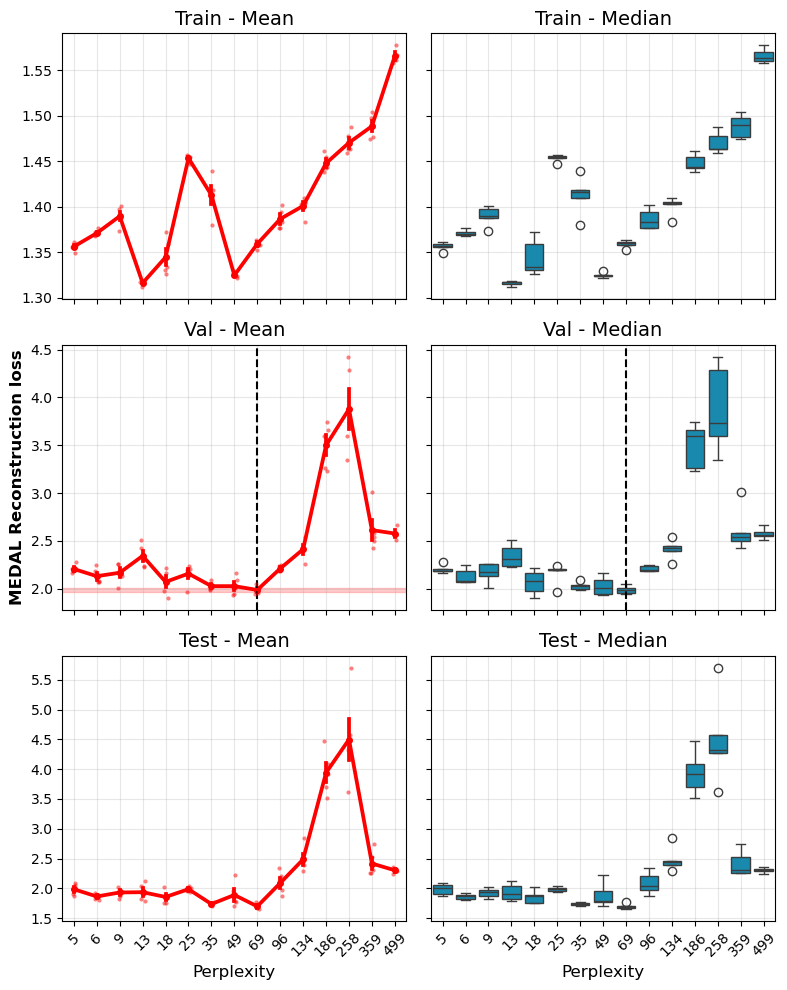

In [17]:
analysis = pd.DataFrame(macaque_umap_res_dict)
analysis.sort_values(by='n_neighbors', inplace=True)
test_stats = analysis[analysis.split == "Val"].groupby('n_neighbors')['recon_loss'].agg(['mean', 'median', 'sem'])
tsne_argmin_mean = test_stats['mean'].idxmin()
tsne_argmin_median = test_stats['median'].idxmin()
tsne_one_std_range = (test_stats.loc[tsne_argmin_mean, "mean"] - test_stats.loc[tsne_argmin_mean, "sem"], 
                test_stats.loc[tsne_argmin_mean, "mean"] + test_stats.loc[tsne_argmin_mean, "sem"])
tsne_one_std_param_choice = test_stats.loc[(test_stats['mean'] <= tsne_one_std_range[1]) & 
                                           (test_stats['mean'] >= tsne_one_std_range[0])].index.min()
x_coords = range(-1, len(test_stats)+1)

unique_neighbors = sorted(analysis['n_neighbors'].unique())
pos_mean = unique_neighbors.index(tsne_argmin_mean)
pos_median = unique_neighbors.index(tsne_argmin_median)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(8, 10), sharey='row', sharex=True)
for i, split in enumerate(['Train','Val', 'Test']):
    subset = analysis[analysis.split == split]
    
    # Left Column: Pointplot + Stripplot
    ax_point = axes[i, 0]
    sns.pointplot(data=subset, x="n_neighbors", y="recon_loss", errorbar="se", 
                  color="red", ax=ax_point, markersize=3)
    sns.stripplot(data=subset, x="n_neighbors", y="recon_loss", 
                  color="red", size=3, alpha=0.5, ax=ax_point)
    
    ax_point.set_title(f"{split} - Mean", fontsize=14)
    
    # Right Column: Boxplot
    ax_box = axes[i, 1]
    sns.boxplot(data=subset, x="n_neighbors", y="recon_loss", ax=ax_box, color='#0096C7')
    ax_box.set_title(f"{split} - Median", fontsize=14)
    
    for ax in [ax_point, ax_box]:
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Perplexity", fontsize=12)
        ax.set_ylabel("")
        plt.setp(ax.get_xticklabels(), rotation=45, ha='center')
        
    if split == "Val":
        ax_point.axvline(x=test_stats.index.get_loc(tsne_one_std_param_choice), ls='--', c='black')
        ax_box.axvline(x=pos_median, ls='--', c='black')

axes[1,0].fill_between(
    x_coords, 
    tsne_one_std_range[0], 
    tsne_one_std_range[1], 
    color="red", 
    alpha=0.2, 
    label='1 SEM'
)
axes[1,0].set_xlim(-0.5,14.5)
axes[1,0].set_ylabel("MEDAL Reconstruction loss", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [5]:
import pickle
teacher_embed = np.load(
            Path(PATH_PREFIX) / f"macaque2/embeddings/data_umap_69_0.1_train.npy"
        )
X_og, X_test, y_og, y_test = load_and_split("macaque2", test_size=0.2, seed=0, labels=True)
X, X_val, y, y_val = train_test_split(X_og, y_og, test_size=0.2, random_state=0)

In [7]:
student = load_trained_ae(Path(PATH_PREFIX) / 'macaque2/medal_umap2_69_seed0_ckpts/final.pt',
                input_dim=100,
                hidden_dims=[512] * 4,
                latent_dim=2, batchnorm=True)
student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
student_test_recon, student_test_embed = student(torch.tensor(X_test, dtype=torch.float32))
per_sample_recon = np.mean((student_recon.detach().numpy() - X)**2, axis=1)
per_sample_test_recon = np.mean((student_test_recon.detach().numpy() - X_test)**2, axis=1)

/tmp/ipykernel_11541/1580406936.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0


In [8]:
macaque2 = pd.read_csv(os.path.join(PATH_PREFIX, 'macaque1_pc100.csv'))
macaque3 = pd.read_csv(os.path.join(PATH_PREFIX, 'macaque3_pc100.csv'))
_, macaque2_test = train_test_split(macaque2, test_size=9600, random_state=0)
_, macaque3_test = train_test_split(macaque3, test_size=9600, random_state=0)
X2, y2 = macaque2_test.drop('labels', axis=1).values, macaque2_test['labels'].values
X3, y3 = macaque3_test.drop('labels', axis=1).values, macaque3_test['labels'].values
X2_aug, X3_aug = np.vstack([X2, X_test]), np.vstack([X3, X_test])
y2_aug, y3_aug = np.concatenate([y2, y_test]), np.concatenate([y3, y_test])
m_id2 = np.array(['M1 (OOD)'] * len(y2)+['M2 (in-dist)'] * len(y_test))
m_id3 = np.array(['M3 (OOD)'] * len(y3)+['M2 (in-dist)'] * len(y_test))

batch_recon2, batch_embed2 = student(torch.tensor(X2_aug, dtype=torch.float32))
per_sample_recon_2 = np.mean((batch_recon2.detach().numpy() - X2_aug)**2, axis=1)
batch_recon3, batch_embed3 = student(torch.tensor(X3_aug, dtype=torch.float32))
per_sample_recon_3 = np.mean((batch_recon3.detach().numpy() - X3_aug)**2, axis=1)

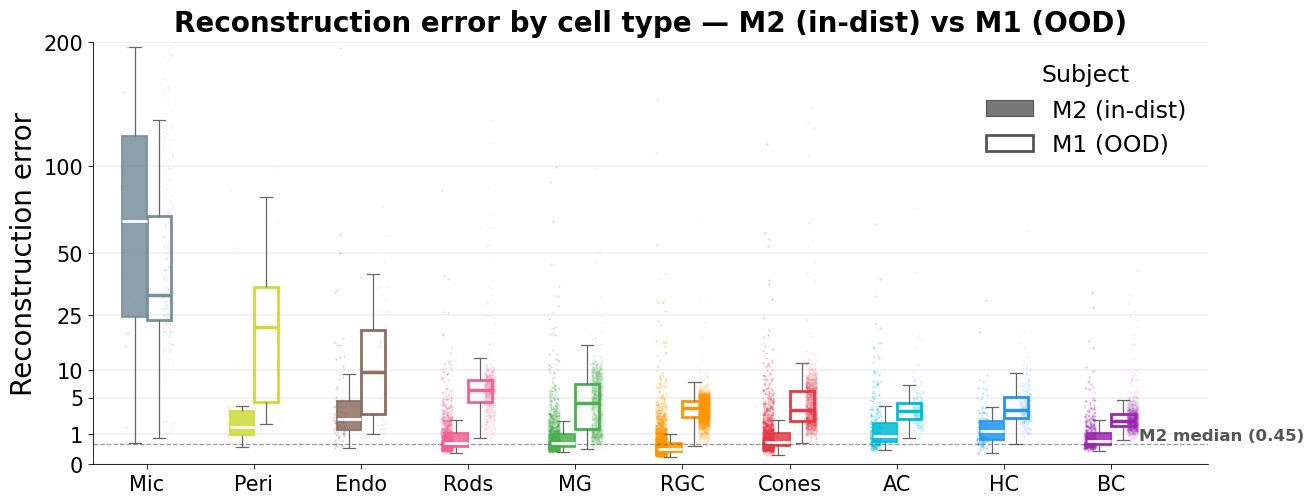

In [23]:
combined = pd.DataFrame({"cell_type": y2_aug, "Subject": m_id2, "recon_err": per_sample_recon_2})
medians = (
    combined
    .groupby(['cell_type', 'Subject'])['recon_err']
    .median()
    .unstack('Subject')
)
medians['diff'] = (medians['M1 (OOD)'] - medians['M2 (in-dist)']).abs()
cell_order = medians.sort_values('diff', ascending=False).index.tolist()
subject_order = ['M2 (in-dist)', 'M1 (OOD)']
n_ct, n_sub   = len(cell_order), len(subject_order)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Liberation Sans', 'DejaVu Sans'],
    'font.size': 11, 'axes.labelsize': 11, 'axes.titlesize': 12,
    'xtick.labelsize': 15, 'ytick.labelsize': 15,
    'axes.linewidth': 0.6, 'xtick.major.width': 0.6, 'ytick.major.width': 0.6,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

fig, ax = plt.subplots(figsize=(13, 5))
n_coll_before = len(ax.collections)
sns.stripplot(
    data=combined, x='cell_type', y='recon_err', hue='Subject',
    order=cell_order, hue_order=subject_order,
    palette={s: '#aaaaaa' for s in subject_order},
    dodge=True, size=1.5, jitter=True, linewidth=0,
    legend=False, ax=ax, zorder=1,
)
new_colls = ax.collections[n_coll_before:]
recolor_by_group(new_colls,
                 lambda c: float(np.mean(c.get_offsets()[:, 0])) if len(c.get_offsets()) else 0.,
                 apply_strip)

n_patch_before = len(ax.patches)
sns.boxplot(
    data=combined, x='cell_type', y='recon_err', hue='Subject',
    order=cell_order, hue_order=subject_order,
    palette={s: '#aaaaaa' for s in subject_order},
    width=0.45, showcaps=True,
    boxprops={'linewidth': 1.5},
    medianprops={'linewidth': 2.0, 'color': 'white'},
    whiskerprops={'linewidth': 0.9},
    capprops={'linewidth': 0.9},
    showfliers=False, dodge=True, ax=ax, zorder=2,
)
new_patches = [p for p in ax.patches[n_patch_before:]
               if isinstance(p, mpatches.PathPatch)]

recolor_by_group(new_patches,
                 lambda p: float(np.mean(p.get_path().vertices[:, 0])),
                 apply_box)

for line in ax.lines:
    x_data = line.get_xdata()
    if len(x_data) == 2 and line.get_linewidth() >= 1.8:
        x_mid = float(np.mean(x_data))
        ci = np.clip(int(round(x_mid)), 0, n_ct - 1)
        color = c_dict[cell_order[ci]]
        if x_mid > ci:
            line.set_color(color)       
            line.set_linewidth(2.5)
        else:
            line.set_color('white')    

m1_median = combined.loc[combined['Subject'] == 'M2 (in-dist)', 'recon_err'].median()
ax.axhline(m1_median, ls='--', lw=0.9, color='#555555', alpha=0.6)
ax.text(n_ct + 0.8, m1_median * 1.15,
        f'M2 median ({m1_median:.2f})',
        fontsize=12, fontweight='bold', color='#555555', va='bottom', ha='right')

ax.set_yscale('function', functions=(
    lambda x: np.sqrt(np.clip(x, 0, None)),  
    lambda x: x**2
))
ax.set_xlim(-0.5, n_ct - 0.5 + 0.4)
ax.set_ylabel('Reconstruction error', labelpad=4, fontsize=20)
ax.set_xlabel('')
ax.set_title('Reconstruction error by cell type — M2 (in-dist) vs M1 (OOD)',
             fontsize=20, fontweight='bold', pad=8)
ymax = combined['recon_err'].max()
ax.set_ylim(0, 200)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(0.6)
ax.grid(axis='y', linewidth=0.35, color='gray', alpha=0.4, zorder=0)
ax.set_axisbelow(True)

ax.set_yticks([0, 1, 5, 10, 25, 50, 100, 200])

legend_handles = [
    mpatches.Patch(facecolor='#777777', edgecolor='#555555',
                   linewidth=0.8, label='M2 (in-dist)'),
    mpatches.Patch(facecolor='none', edgecolor='#555555',
                   linewidth=2.0, label='M1 (OOD)'),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=17,
          loc='upper right', title='Subject', title_fontsize=17)

plt.tight_layout(pad=0.5)
plt.show()

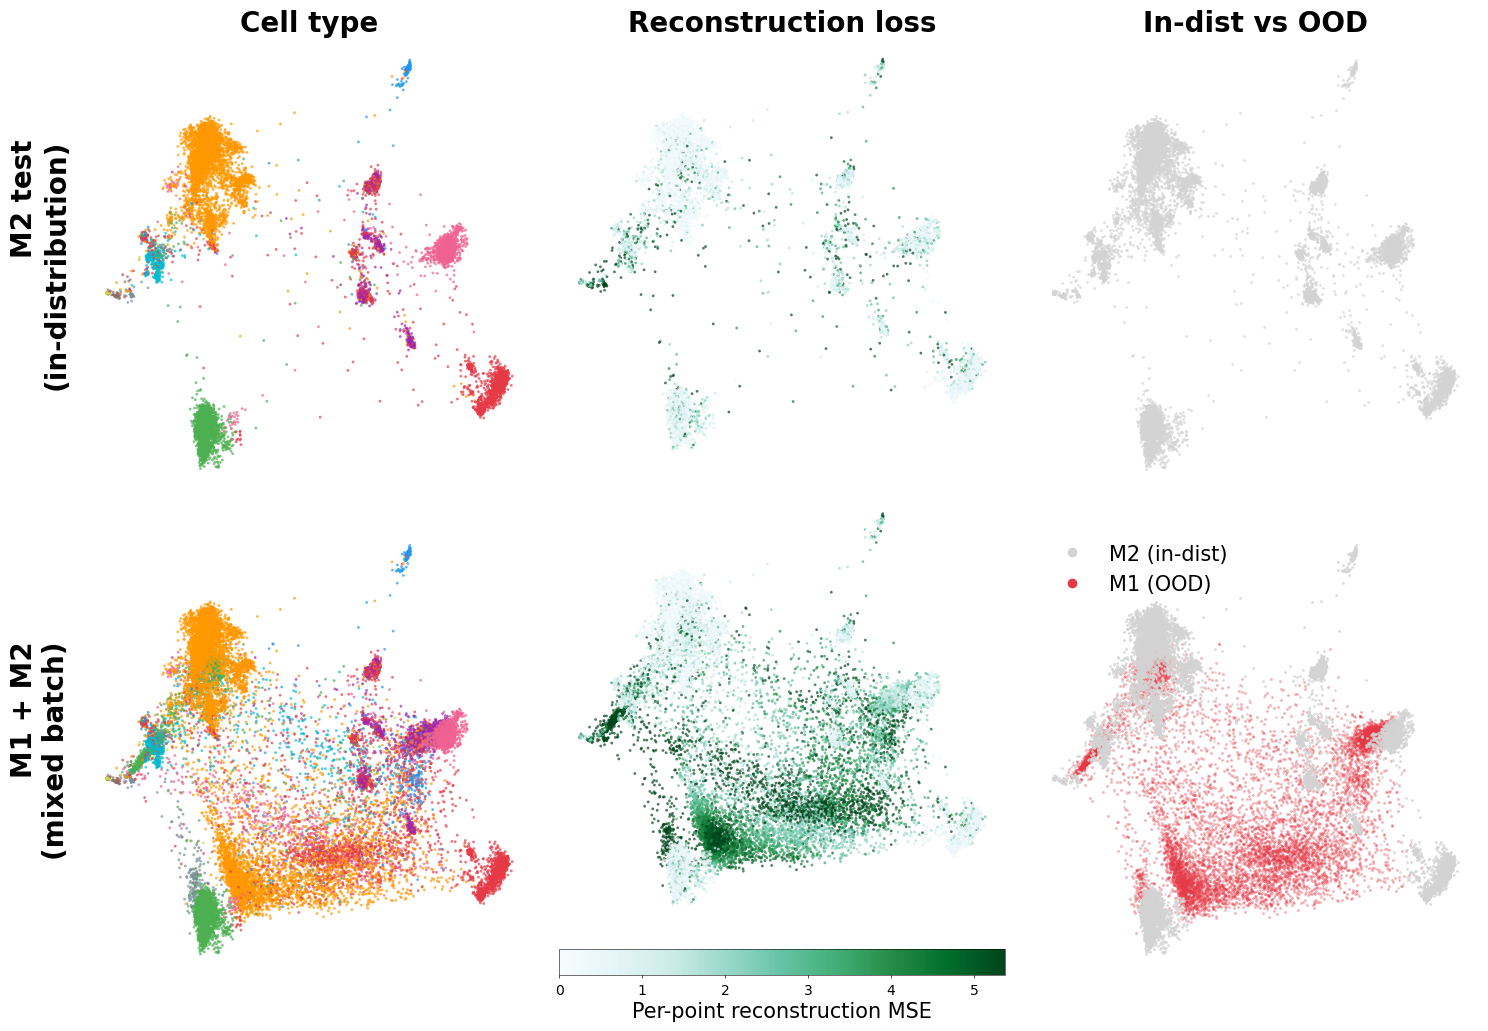

In [10]:
plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.sans-serif':  ['Arial', 'Liberation Sans', 'DejaVu Sans'],
    'font.size':        11,
    'pdf.fonttype':     42,
    'ps.fonttype':      42,
})

recon_cmap = sns.color_palette("BuGn", as_cmap=True)

# shared recon colorscale across both rows
all_recon   = np.concatenate([per_sample_test_recon, per_sample_recon_2])
vmax_shared = np.quantile(all_recon, 0.9)
shared_norm = plt.Normalize(vmin=0, vmax=vmax_shared)


indist_color = '#D3D3D3'   # grey = M1 (in-distribution)
ood_color    = '#E63946'   # red  = M2 (out-of-distribution)
ood_labels_test = np.array(['M2 (in-dist)'] * len(y_test))
ood_labels_mix  = np.array(['M1 (OOD)'] * len(y2)+['M2 (in-dist)'] * len(y_test))

ood_palette = {
    'M2 (in-dist)': indist_color,
    'M1 (OOD)':     ood_color,
}

fig = plt.figure(figsize=(16, 11))
gs_outer = GridSpec(1, 3, figure=fig, wspace=0.06,
                    left=0.1, right=0.97, top=0.93, bottom=0.08)

gs_col0 = GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_outer[0], hspace=0.08)
gs_col2 = GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_outer[2], hspace=0.08)
gs_col1 = GridSpecFromSubplotSpec(3, 1, subplot_spec=gs_outer[1],
                                   height_ratios=[1, 1, 0.06], hspace=0.08)

ax_test_cell  = fig.add_subplot(gs_col0[0])
ax_mix_cell   = fig.add_subplot(gs_col0[1])

ax_test_recon = fig.add_subplot(gs_col1[0])
ax_mix_recon  = fig.add_subplot(gs_col1[1])
cax           = fig.add_subplot(gs_col1[2])  

ax_test_ood   = fig.add_subplot(gs_col2[0])
ax_mix_ood    = fig.add_subplot(gs_col2[1])


col_titles = ['Cell type', 'Reconstruction loss', 'In-dist vs OOD']
for ax, title in zip([ax_test_cell, ax_test_recon, ax_test_ood], col_titles):
    ax.set_title(title, fontsize=20, fontweight='bold', pad=6)

for ax, label in [(ax_test_cell, 'M2 test\n(in-distribution)'),
                  (ax_mix_cell,  'M1 + M2\n(mixed batch)')]:
    bbox = ax.get_position()
    fig.text(bbox.x0 - 0.01,
             bbox.y0 + bbox.height / 2,
             label, ha='right', va='center',
             fontsize=20, fontweight='bold', rotation=90)

Z_test = student_test_embed.detach().numpy() if hasattr(student_test_embed, 'detach') \
         else np.array(student_test_embed)
ax_test_cell.scatter(Z_test[:, 0], Z_test[:, 1],
                     c=[c_dict[ct] for ct in y_test],
                     s=4, linewidths=0, alpha=0.7, rasterized=True)
clean_ax(ax_test_cell)
ax_test_recon.scatter(Z_test[:, 0], Z_test[:, 1],
                      c=per_sample_test_recon, cmap=recon_cmap,
                      norm=shared_norm, s=4, linewidths=0,
                      alpha=0.7, rasterized=True)
clean_ax(ax_test_recon)
ax_test_ood.scatter(Z_test[:, 0], Z_test[:, 1],
                    c=indist_color, s=4, linewidths=0,
                    alpha=0.7, rasterized=True)
clean_ax(ax_test_ood)
Z_mix = batch_embed2.detach().numpy() if hasattr(batch_embed2, 'detach') \
        else np.array(batch_embed2)

ax_mix_cell.scatter(Z_mix[:, 0], Z_mix[:, 1],
                    c=[c_dict.get(ct, '#aaaaaa') for ct in y2_aug],
                    s=4, linewidths=0, alpha=0.7, rasterized=True)
clean_ax(ax_mix_cell)
ax_mix_recon.scatter(Z_mix[:, 0], Z_mix[:, 1],
                     c=per_sample_recon_2, cmap=recon_cmap,
                     norm=shared_norm, s=4, linewidths=0,
                     alpha=0.7, rasterized=True)
clean_ax(ax_mix_recon)

# in-dist vs OOD — key panel
m2_mask = ood_labels_mix == 'M1 (OOD)'
m1_mask = ood_labels_mix == 'M2 (in-dist)'

ax_mix_ood.scatter(Z_mix[m2_mask, 0], Z_mix[m2_mask, 1],
                   c=ood_color, s=4, linewidths=0,
                   alpha=0.4, rasterized=True, zorder=1)   
ax_mix_ood.scatter(Z_mix[m1_mask, 0], Z_mix[m1_mask, 1],
                   c=indist_color, s=4, linewidths=0,
                   alpha=0.8, rasterized=True, zorder=2) 
clean_ax(ax_mix_ood)

sm = plt.cm.ScalarMappable(cmap=recon_cmap, norm=shared_norm)
cb = fig.colorbar(sm, cax=cax, orientation='horizontal')
cb.set_label('Per-point reconstruction MSE', fontsize=15, labelpad=3)
cb.ax.tick_params(labelsize=10, width=0.5, length=2.5)
cb.outline.set_linewidth(0.4)

ood_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=color, markersize=8, label=label)
    for label, color in ood_palette.items()
]
ax_mix_ood.legend(
    handles=ood_handles,
    loc='upper left', frameon=False,
    facecolor='white', edgecolor='#cccccc',
    framealpha=0.9, fontsize=15,
)

fig.subplots_adjust(left=0.1)

plt.show()